# EDA: J1 League 2024 — Merged Tracking × Event Data

This notebook validates the output of `merge_j1_2024.py` and visualizes player
positions during a **goal kick** for match **1410827** (Nagoya Grampus vs Kashima Antlers, 2024-02-23).

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mplsoccer import Pitch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

MATCH_FILE = 'data/merged_j1_2024/match_1410827.parquet'
df = pd.read_parquet(MATCH_FILE)

print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}):', df.columns.tolist())

Shape: (484484, 50)
Columns (50): ['frame', 'period', 'timestamp_seconds', 'ball_x', 'ball_y', 'ball_z', 'ball_detected', 'possession_player_id', 'possession_group', 'player_id', 'player_x', 'player_y', 'player_detected', 'player_name', 'skc_team_id', 'jersey_number', 'player_role', 'is_home', 'event_id', 'event_type', 'event_minute', 'event_second', 'event_timestamp', 'event_duration', 'event_sb_team_id', 'event_team_name', 'event_sb_player_id', 'event_player_name', 'possession_team_id', 'possession_team_name', 'play_pattern', 'event_location_x', 'event_location_y', 'pass_end_x', 'pass_end_y', 'carry_end_x', 'carry_end_y', 'shot_end_x', 'shot_end_y', 'obv_for_net', 'obv_against_net', 'obv_total_net', 'obv_for_before', 'obv_for_after', 'obv_against_before', 'obv_against_after', 'skc_match_id', 'sb_match_id', 'home_team', 'away_team']


## 1. Data Overview

In [2]:
print('=== Basic Info ===')
print(f'Match:       {df["home_team"].iloc[0]} vs {df["away_team"].iloc[0]}')
print(f'SKC match ID: {df["skc_match_id"].iloc[0]}')
print(f'SB match ID:  {df["sb_match_id"].iloc[0]}')
print(f'Periods:      {sorted(df["period"].unique())}')
print(f'Total rows:   {len(df):,}')
print(f'Unique frames:{df["frame"].nunique():,}')
print(f'Unique players:{df["player_id"].nunique()}')
print()
print('=== Players ===')
players = df.drop_duplicates('player_id')[['player_id','player_name','skc_team_id','jersey_number','player_role','is_home']]
print(players.sort_values(['is_home','jersey_number'], ascending=[False,True]).to_string(index=False))

=== Basic Info ===
Match:       Nagoya Grampus vs Kashima Antlers
SKC match ID: 1410827
SB match ID:  3925227
Periods:      [1, 2]
Total rows:   484,484
Unique frames:22,022
Unique players:32

=== Players ===
 player_id      player_name  skc_team_id  jersey_number              player_role  is_home
      7698      M. Langerak         1461              1               Goalkeeper     True
     26960        Y. Nogami         1461              2        Right Center Back     True
    727006         S. Inoue         1461              4         Left Center Back     True
     73575       H. Yoshida         1461              5         Left Center Back     True
    254407         R. Izumi         1461              7            Left Midfield     True
     73817           Patric         1461             10           Center Forward     True
     26959     T. Morishima         1461             14           Right Midfield     True
     73574       S. Inagaki         1461             15       Defensive

In [3]:
print('=== NaN Rate by Column ===')
nan_rates = df.isna().mean().sort_values(ascending=False) * 100
print(nan_rates[nan_rates > 0].to_string())

=== NaN Rate by Column ===
shot_end_y              99.668513
shot_end_x              99.668513
carry_end_y             78.743983
carry_end_x             78.743983
possession_player_id    73.122332
pass_end_y              70.016347
pass_end_x              70.016347
event_duration          38.475161
event_location_y        36.767778
event_location_x        36.767778
event_sb_player_id      36.563437
event_player_name       36.563437
event_id                36.418127
event_timestamp         36.418127
event_sb_team_id        36.418127
event_minute            36.418127
event_type              36.418127
event_second            36.418127
possession_team_id      36.418127
possession_team_name    36.418127
play_pattern            36.418127
event_team_name         36.418127
possession_group        26.246481


In [4]:
print('=== Event Type Distribution ===')
# Count by unique frames (not rows) so duplicates per player don't inflate counts
frame_events = df.drop_duplicates('frame')[['frame','event_type','play_pattern']]
print('By event type (unique frames):')
print(frame_events['event_type'].value_counts().to_string())
print()
print('By play pattern (unique frames):')
print(frame_events['play_pattern'].value_counts().to_string())

=== Event Type Distribution ===
By event type (unique frames):
event_type
Pass               6603
Carry              4681
Pressure            561
Duel                493
Ball Receipt*       453
Ball Recovery       446
Clearance           211
Shot                118
Foul Committed      113
Goal Keeper         110
50/50                45
Block                28
Injury Stoppage      25
Miscontrol           21
Substitution         20
Half End             20
Interception         17
Shield               15
Tactical Shift       10
Dribbled Past         7
Offside               3
Starting XI           2

By play pattern (unique frames):
play_pattern
Regular Play      5174
From Throw In     3714
From Free Kick    2018
From Goal Kick    1481
From Corner       1062
From Keeper        351
From Kick Off      148
From Counter        54


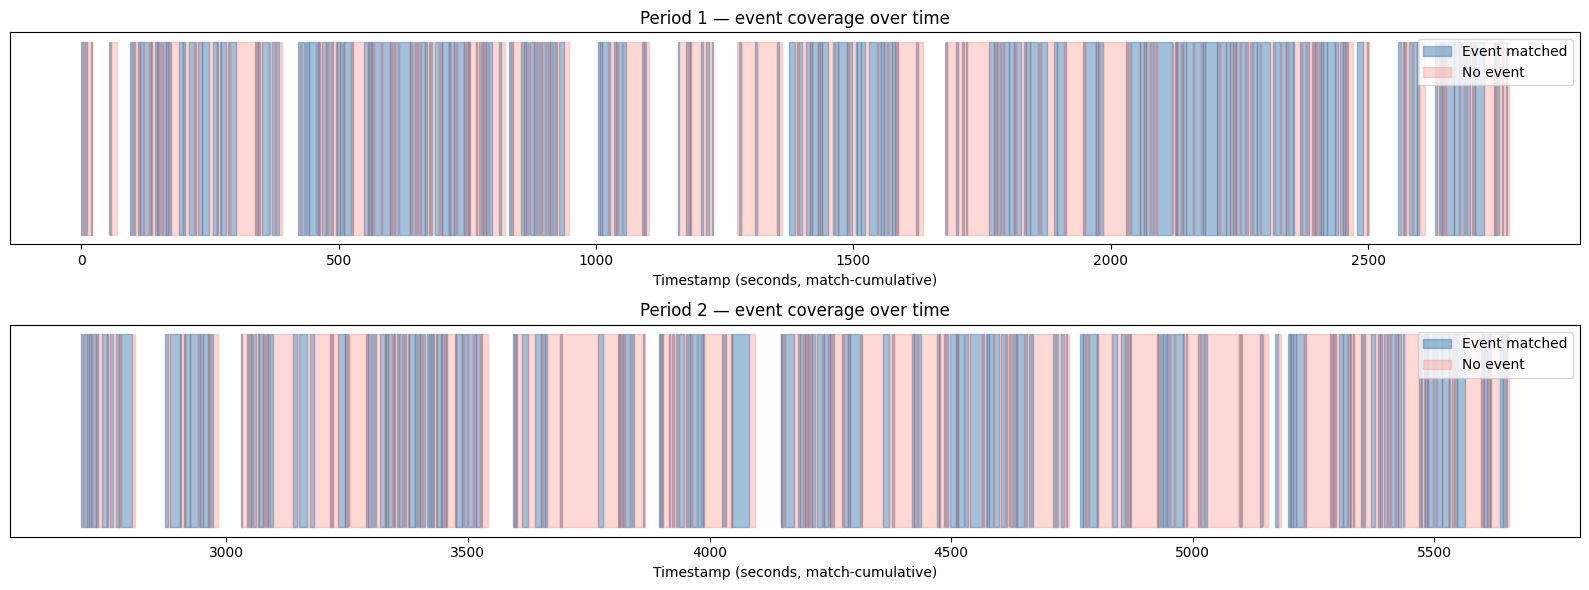

Overall event coverage: 63.6% of tracking rows have a matched event


In [5]:
# Timeline: event coverage across the match
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=False)

for ax, period in zip(axes, [1, 2]):
    p = df[df['period'] == period].drop_duplicates('frame').copy()
    has_event = p['event_type'].notna()
    
    t = p['timestamp_seconds']
    ax.fill_between(t, 0, 1, where=has_event, alpha=0.5, color='steelblue', label='Event matched')
    ax.fill_between(t, 0, 1, where=~has_event, alpha=0.3, color='salmon', label='No event')
    ax.set_title(f'Period {period} — event coverage over time')
    ax.set_xlabel('Timestamp (seconds, match-cumulative)')
    ax.set_yticks([])
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

covered = df['event_type'].notna().mean() * 100
print(f'Overall event coverage: {covered:.1f}% of tracking rows have a matched event')

## 2. Coordinate Sanity Check

SkillCorner tracking uses **meters from pitch centre**: x ∈ [−52.5, 52.5], y ∈ [−34, 34].

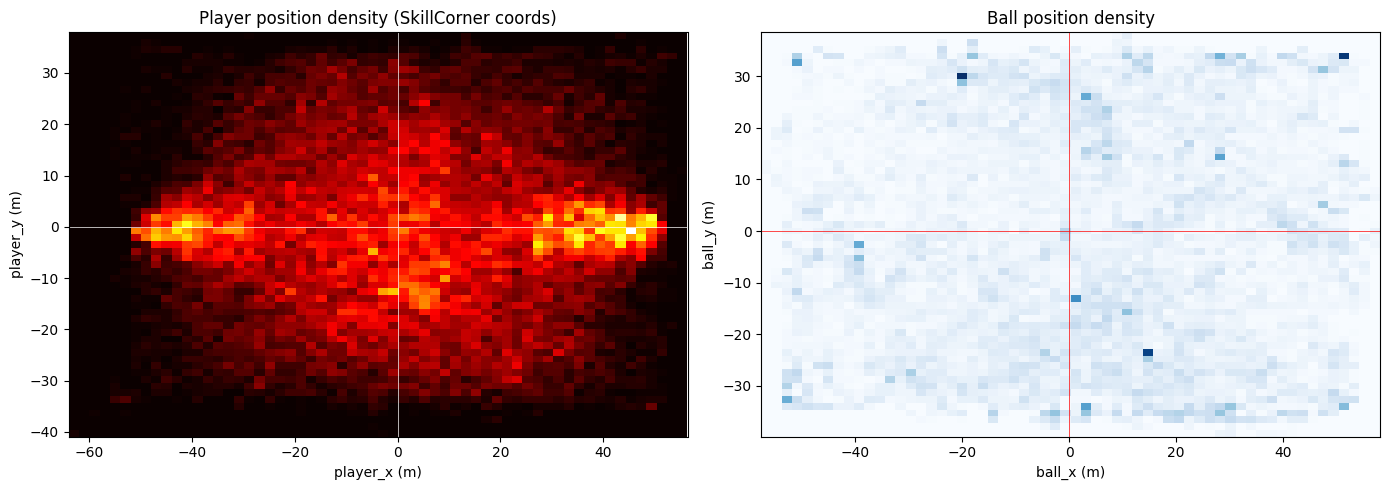

Player x range: -64.13 to 56.6
Player y range: -40.93 to 38.04
Ball  x range: -57.58 to 58.1
Ball  y range: -39.8 to 38.5


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Player positions heatmap
ax = axes[0]
sample = df[df['player_x'].notna() & df['player_y'].notna()].sample(min(50000, len(df)), random_state=42)
ax.hist2d(sample['player_x'], sample['player_y'], bins=60, cmap='hot')
ax.set_xlabel('player_x (m)')
ax.set_ylabel('player_y (m)')
ax.set_title('Player position density (SkillCorner coords)')
ax.axhline(0, color='white', lw=0.5)
ax.axvline(0, color='white', lw=0.5)

# Ball positions
ax2 = axes[1]
ball_sample = df[df['ball_x'].notna()].drop_duplicates('frame').sample(min(20000, len(df)), random_state=42)
ax2.hist2d(ball_sample['ball_x'], ball_sample['ball_y'], bins=60, cmap='Blues')
ax2.set_xlabel('ball_x (m)')
ax2.set_ylabel('ball_y (m)')
ax2.set_title('Ball position density')
ax2.axhline(0, color='red', lw=0.5)
ax2.axvline(0, color='red', lw=0.5)

plt.tight_layout()
plt.show()

print('Player x range:', df['player_x'].min(), 'to', df['player_x'].max())
print('Player y range:', df['player_y'].min(), 'to', df['player_y'].max())
print('Ball  x range:', df['ball_x'].min(), 'to', df['ball_x'].max())
print('Ball  y range:', df['ball_y'].min(), 'to', df['ball_y'].max())

## 3. Goal Kick Visualization

Find a **goal kick** frame (play pattern = 'From Goal Kick' with a Pass event)  
and plot all 22 player positions on a pitch.

In [7]:
# Find frames that are goal kick pass events
gk_pass_frames = df[
    (df['play_pattern'] == 'From Goal Kick') &
    (df['event_type'] == 'Pass') &
    df['event_location_x'].notna()
]['frame'].unique()

print(f'Frames with goal kick Pass events: {len(gk_pass_frames)}')

# Pick the first one that has enough players
chosen_frame = None
for fid in gk_pass_frames:
    frame_rows = df[df['frame'] == fid]
    n_players = frame_rows['player_name'].notna().sum()
    if n_players >= 15:
        chosen_frame = fid
        break

if chosen_frame is None:
    chosen_frame = gk_pass_frames[0]

frame_data = df[df['frame'] == chosen_frame].copy()
event_row  = frame_data.iloc[0]  # event info is same for all rows in a frame

print(f'\nSelected frame: {chosen_frame}')
print(f'Period: {event_row["period"]},  Timestamp: {event_row["timestamp_seconds"]:.1f}s')
print(f'Event:  {event_row["event_type"]} by {event_row["event_player_name"]} ({event_row["event_team_name"]})')
print(f'Play pattern: {event_row["play_pattern"]}')
print(f'Event location (StatsBomb): ({event_row["event_location_x"]:.1f}, {event_row["event_location_y"]:.1f})')
print(f'Pass end location: ({event_row["pass_end_x"]}, {event_row["pass_end_y"]})')
print(f'Players in frame: {len(frame_data)}')

Frames with goal kick Pass events: 726

Selected frame: 4238
Period: 1,  Timestamp: 422.8s
Event:  Pass by Tojiro Kubo (Nagoya Grampus)
Play pattern: From Goal Kick
Event location (StatsBomb): (44.1, 39.1)
Pass end location: (99.9, 47.3)
Players in frame: 22


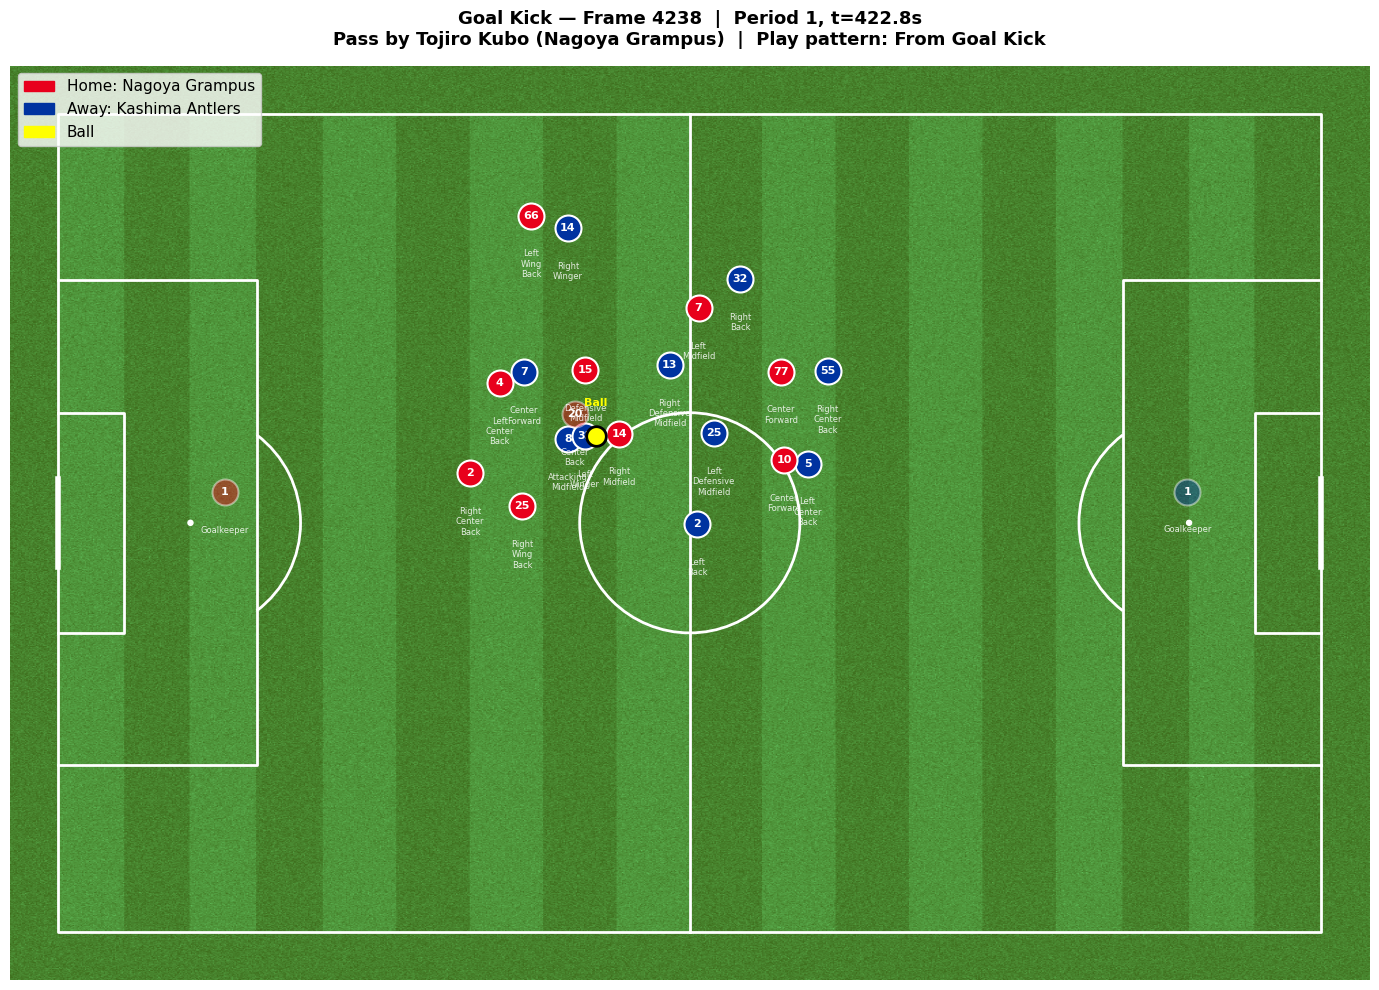

Saved to goal_kick_frame.png


In [8]:
# ── Pitch dimensions ──────────────────────────────────────────────────────────
# SkillCorner uses metres from centre: standard J1 pitch is 105m x 68m
# mplsoccer 'skillcorner' pitch type handles this coordinate system natively.

pitch = Pitch(
    pitch_type='skillcorner',
    pitch_length=105,
    pitch_width=68,
    pitch_color='grass',
    line_color='white',
    stripe=True,
    linewidth=2,
)

fig, ax = pitch.draw(figsize=(16, 10))

home_color = '#E8001C'   # Nagoya Grampus red
away_color = '#0033A0'   # Kashima Antlers blue

for _, row in frame_data.iterrows():
    if pd.isna(row['player_x']) or pd.isna(row['player_y']):
        continue

    color  = home_color if row['is_home'] else away_color
    marker = 'o'
    alpha  = 1.0 if row['player_detected'] else 0.45

    # Plot player dot
    ax.scatter(
        row['player_x'], row['player_y'],
        s=350, color=color, edgecolors='white', linewidths=1.5,
        zorder=5, alpha=alpha,
    )

    # Jersey number label
    jersey = int(row['jersey_number']) if pd.notna(row['jersey_number']) else '?'
    ax.text(
        row['player_x'], row['player_y'],
        str(jersey), fontsize=8, ha='center', va='center',
        color='white', fontweight='bold', zorder=6,
    )

    # Role label below dot
    role_short = (row['player_role'] or '').replace(' ', '\n')
    ax.text(
        row['player_x'], row['player_y'] - 2.8,
        role_short, fontsize=6, ha='center', va='top',
        color='white', alpha=0.85, zorder=6,
    )

# Ball position
ball_x, ball_y = event_row['ball_x'], event_row['ball_y']
if pd.notna(ball_x) and pd.notna(ball_y):
    ax.scatter(ball_x, ball_y, s=200, color='yellow', edgecolors='black',
               linewidths=2, zorder=10, marker='o')
    ax.text(ball_x, ball_y + 2.5, 'Ball', fontsize=8, ha='center',
            color='yellow', fontweight='bold', zorder=11)

# Legend
home_patch = mpatches.Patch(color=home_color, label=f'Home: {event_row["home_team"]}')
away_patch = mpatches.Patch(color=away_color, label=f'Away: {event_row["away_team"]}')
ball_patch = mpatches.Patch(color='yellow', label='Ball')
ax.legend(handles=[home_patch, away_patch, ball_patch],
          loc='upper left', fontsize=11, framealpha=0.8)

# Title
ax.set_title(
    f'Goal Kick — Frame {chosen_frame}  |  Period {int(event_row["period"])}, '
    f't={event_row["timestamp_seconds"]:.1f}s\n'
    f'{event_row["event_type"]} by {event_row["event_player_name"]} '
    f'({event_row["event_team_name"]})  |  '
    f'Play pattern: {event_row["play_pattern"]}',
    fontsize=13, fontweight='bold', pad=15,
)

plt.tight_layout()
plt.savefig('goal_kick_frame.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to goal_kick_frame.png')

## 4. Goal Kick Sequence — First 5 Frames

Show how player positions evolve in the 5 tracking frames immediately following the goal kick.

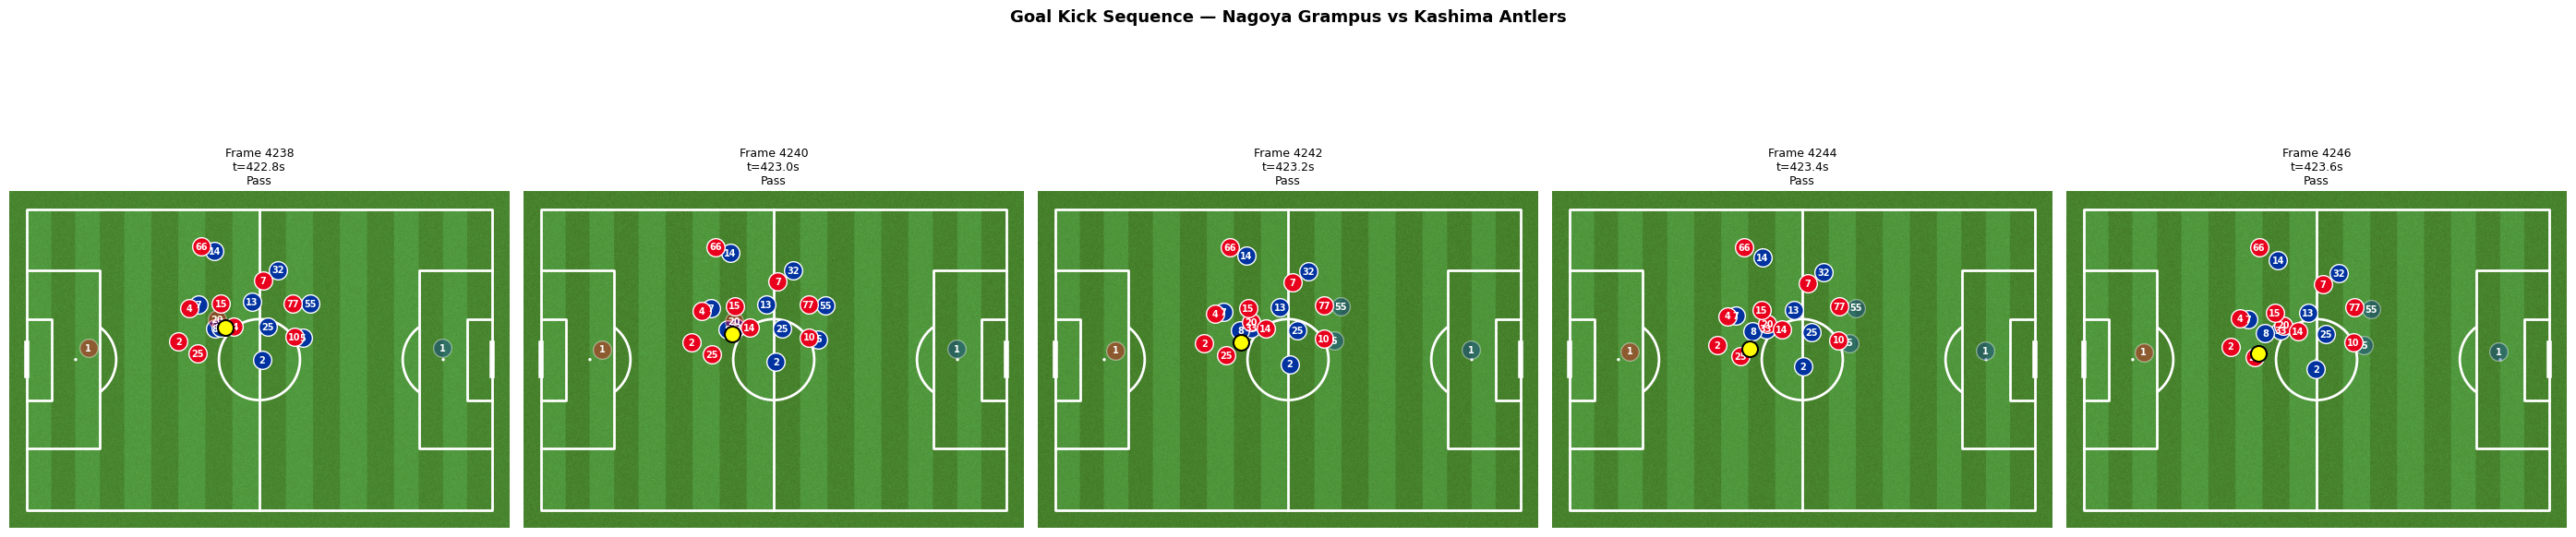

Saved to goal_kick_sequence.png


In [9]:
# Get the 5 frames starting from chosen_frame
# (frames are not necessarily consecutive integers — find the actual next frames by timestamp)
all_frames_sorted = sorted(df['frame'].unique())
frame_idx = all_frames_sorted.index(chosen_frame)
seq_frames = all_frames_sorted[frame_idx: frame_idx + 5]

fig, axes = plt.subplots(1, 5, figsize=(28, 7))

for ax, fid in zip(axes, seq_frames):
    pitch.draw(ax=ax)
    fdata = df[df['frame'] == fid]
    t_val = fdata['timestamp_seconds'].iloc[0]

    for _, row in fdata.iterrows():
        if pd.isna(row['player_x']) or pd.isna(row['player_y']):
            continue
        color = home_color if row['is_home'] else away_color
        alpha = 1.0 if row['player_detected'] else 0.4
        ax.scatter(row['player_x'], row['player_y'],
                   s=200, color=color, edgecolors='white', linewidths=1,
                   zorder=5, alpha=alpha)
        jersey = int(row['jersey_number']) if pd.notna(row['jersey_number']) else ''
        ax.text(row['player_x'], row['player_y'], str(jersey),
                fontsize=7, ha='center', va='center',
                color='white', fontweight='bold', zorder=6)

    # Ball
    bx, by = fdata['ball_x'].iloc[0], fdata['ball_y'].iloc[0]
    if pd.notna(bx):
        ax.scatter(bx, by, s=150, color='yellow', edgecolors='black',
                   linewidths=1.5, zorder=10)

    evt_type = fdata['event_type'].iloc[0]
    ax.set_title(f'Frame {fid}\nt={t_val:.1f}s\n{evt_type}', fontsize=9)

plt.suptitle(
    f'Goal Kick Sequence — {event_row["home_team"]} vs {event_row["away_team"]}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('goal_kick_sequence.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to goal_kick_sequence.png')

## 5. Merge Quality Check

Verify that event timestamps in the merged data are close to the tracking frame timestamps.

Temporal gap between tracking frame and matched event (seconds):
count    308044.000000
mean          0.395645
std           0.263901
min           0.000000
25%           0.174000
50%           0.360000
75%           0.590000
max           1.000000
Name: temporal_gap, dtype: float64


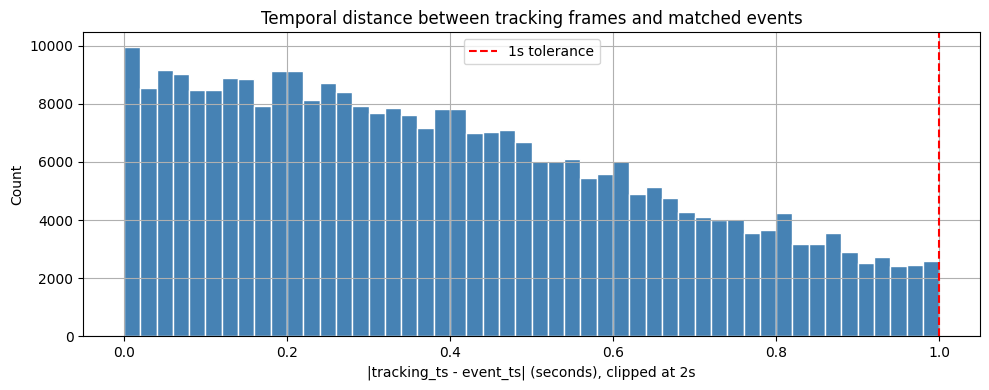

In [10]:
# Compute temporal distance between tracking frame and matched event
# For period 2 we need period-relative timestamps
matched = df[df['event_type'].notna()].copy()

def period_relative_ts(row):
    """Approximate period-relative tracking timestamp."""
    p = row['period']
    t = row['timestamp_seconds']
    grp = df[(df['period'] == p) & df['timestamp_seconds'].notna()]
    return t - grp['timestamp_seconds'].min()

# Compute per-period min timestamp once
period_min_ts = df.groupby('period')['timestamp_seconds'].min()

matched = matched.copy()
matched['tracking_ts_rel'] = matched['timestamp_seconds'] - matched['period'].map(period_min_ts)

# StatsBomb event timestamp as seconds (already period-relative)
def sb_ts_to_sec(ts):
    if pd.isna(ts): return np.nan
    try:
        parts = str(ts).split(':')
        return float(parts[0])*3600 + float(parts[1])*60 + float(parts[2])
    except: return np.nan

matched['event_ts_sec'] = matched['event_timestamp'].apply(sb_ts_to_sec)
matched['temporal_gap'] = (matched['tracking_ts_rel'] - matched['event_ts_sec']).abs()

print('Temporal gap between tracking frame and matched event (seconds):')
print(matched['temporal_gap'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
matched['temporal_gap'].clip(upper=2).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('|tracking_ts - event_ts| (seconds), clipped at 2s')
ax.set_ylabel('Count')
ax.set_title('Temporal distance between tracking frames and matched events')
ax.axvline(1.0, color='red', linestyle='--', label='1s tolerance')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
print('Summary statistics')
print('='*50)
print(f'Total tracking rows:          {len(df):,}')
print(f'Unique frames:                {df["frame"].nunique():,}')
print(f'Rows with event matched:      {df["event_type"].notna().sum():,} ({df["event_type"].notna().mean()*100:.1f}%)')
print(f'Unique event types seen:      {df["event_type"].nunique()}')
print(f'Goal kick frames:             {df[df["play_pattern"]=="From Goal Kick"]["frame"].nunique():,}')
print(f'Pass events frames:           {df[df["event_type"]=="Pass"]["frame"].nunique():,}')
print(f'Shot events frames:           {df[df["event_type"]=="Shot"]["frame"].nunique():,}')
print()
print('Median temporal gap to matched event:', matched['temporal_gap'].median().round(3), 's')
print('Max temporal gap (p99):             ', matched['temporal_gap'].quantile(0.99).round(3), 's')

Summary statistics
Total tracking rows:          484,484
Unique frames:                22,022
Rows with event matched:      308,044 (63.6%)
Unique event types seen:      22
Goal kick frames:             1,481
Pass events frames:           6,603
Shot events frames:           118

Median temporal gap to matched event: 0.36 s
Max temporal gap (p99):              0.975 s
